# Elastic Net Regression (24h-Ahead Prediction)

**Strategy:**
- Use ELASTIC NET (L1 + L2 regularization)
- Combines Lasso (feature selection) + Ridge (multicollinearity handling)
- Features: Annual patterns (1-4 years ago) + Weekly patterns (2-7 days ago)
- Cross-validation to find optimal alpha and l1_ratio
- Compare with baseline (4-year average)

**Features:**
1. Annual lags: 1yr, 2yr, 3yr, 4yr ago (same day/hour last year)
2. Weekly lags: 4d, 5d, 6d, 7d, 8d, 9d, 10d ago (recent days)

**Elastic Net = α × [ρ × L1 + (1-ρ) × L2]:**
- **L1 (Lasso)**: Feature selection (sparse coefficients)
- **L2 (Ridge)**: Handles multicollinearity (correlated features)
- **alpha (α)**: Overall regularization strength
- **l1_ratio (ρ)**: Balance between L1 and L2 (0=Ridge, 1=Lasso, 0.5=50/50)

**Why Elastic Net for Time Series:**
- Lag features are highly correlated (multicollinearity)
- Lasso picks one randomly → unstable
- Ridge keeps all → no feature selection
- Elastic Net: Best of both worlds!

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [2]:
# Features: Annual + Weekly lags only
ANNUAL_LAGS = ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h']  # 1yr, 2yr, 3yr, 4yr
WEEKLY_LAGS = ['mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h', 'mw_lag_240h']  # 4d-10d
INDICATORS = ['is_blackfriday', 'is_thanksgiving']

ALL_FEATURES = ANNUAL_LAGS + WEEKLY_LAGS + INDICATORS

HORIZON = 24  # Predict 24 hours ahead

# Elastic Net CV parameters
ALPHAS = np.logspace(1, 4, 10)  # 10 alpha values from 1 to 10000
L1_RATIOS = [0, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]  # Mix of L1 and L2
# 0.0 = 100% Ridge (strong multicollinearity handling)
# 0.5 = 50% Lasso + 50% Ridge (balanced)
# 1.0 = 100% Lasso (pure feature selection)

N_FOLDS_EN = 5  # Inner CV folds for hyperparameter selection

# Year-based CV windows (outer CV)
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

print(f"Configuration:")
print(f"  Model: Elastic Net (L1 + L2 regularization)")
print(f"  Prediction horizon: {HORIZON}h ahead")
print(f"  Annual lags (1-4 years): {ANNUAL_LAGS}")
print(f"  Weekly lags (3-9 days): {WEEKLY_LAGS}")
print(f"  Total features: {len(ALL_FEATURES)}")
print(f"  Alpha range: {ALPHAS[0]:.4f} to {ALPHAS[-1]:.2f} ({len(ALPHAS)} values)")
print(f"  L1 ratios: {L1_RATIOS}")
print(f"  Elastic Net CV folds: {N_FOLDS_EN}")
print(f"  Outer CV folds: {len(CV_WINDOWS)} (year-based)")
print(f"  Feature scaling: Not applied (similar value ranges)")

Configuration:
  Model: Elastic Net (L1 + L2 regularization)
  Prediction horizon: 24h ahead
  Annual lags (1-4 years): ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h']
  Weekly lags (3-9 days): ['mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h', 'mw_lag_240h']
  Total features: 13
  Alpha range: 10.0000 to 10000.00 (10 values)
  L1 ratios: [0, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
  Elastic Net CV folds: 5
  Outer CV folds: 5 (year-based)
  Feature scaling: Not applied (similar value ranges)


## Load Data

In [3]:
print("="*80)
print("Loading Data")
print("="*80)

# Load
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

# Filter BF period
bf_df = df[(df['days_from_bf'] >= -9) & (df['days_from_bf'] <= 0)].copy()
bf_df = bf_df.sort_values(['load_area', 'datetime_beginning_ept']).reset_index(drop=True)

# Create target: 24h ahead
bf_df['target_24h'] = bf_df.groupby('load_area')['mw'].shift(-24)
bf_df = bf_df.dropna(subset=['target_24h'])

print(f"BF period data: {len(bf_df):,} rows")
print(f"Years: {sorted(bf_df['year'].unique())}")

# Check feature availability
available_features = [f for f in ALL_FEATURES if f in bf_df.columns]
missing_features = [f for f in ALL_FEATURES if f not in bf_df.columns]

print(f"\nFeature availability:")
print(f"  Available: {len(available_features)}/{len(ALL_FEATURES)}")
if missing_features:
    print(f"  Missing: {missing_features}")

# Use only available features
FEATURES = available_features
print(f"\nUsing {len(FEATURES)} features: {FEATURES}")

Loading Data
BF period data: 63,096 rows
Years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]

Feature availability:
  Available: 12/13
  Missing: ['mw_lag_240h']

Using 12 features: ['mw_lag_8760h', 'mw_lag_17520h', 'mw_lag_26280h', 'mw_lag_35040h', 'mw_lag_96h', 'mw_lag_120h', 'mw_lag_144h', 'mw_lag_168h', 'mw_lag_192h', 'mw_lag_216h', 'is_blackfriday', 'is_thanksgiving']


## Calculate Baseline (4-Year Average)

In [4]:
print("="*80)
print("Calculating Baseline (4-Year Average)")
print("="*80)

# Get load areas (exclude RTO)
load_areas = sorted([a for a in bf_df['load_area'].unique() if a != 'RTO' and a !='AE'])

baseline_results = []

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    area_rmses = []
    
    for window in CV_WINDOWS:
        train_data = area_data[area_data['year'].isin(window['train_years'])]
        test_data = area_data[area_data['year'] == window['test_year']]
        
        if len(test_data) == 0:
            continue
        
        # Baseline: average of training years
        baseline_pred = train_data['mw'].mean()
        
        # Evaluate
        y_true = test_data['target_24h']
        y_pred = np.full(len(y_true), baseline_pred)
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        area_rmses.append(rmse)
    
    if area_rmses:
        baseline_results.append({
            'area': area,
            'baseline_rmse': np.mean(area_rmses)
        })

baseline_df = pd.DataFrame(baseline_results)

print(f"\n✓ Baseline calculated for {len(baseline_df)} areas")
print(f"Average baseline RMSE: {baseline_df['baseline_rmse'].mean():.2f}")

Calculating Baseline (4-Year Average)

✓ Baseline calculated for 29 areas
Average baseline RMSE: 359.81


## Train Linear Regression Model

In [5]:
print("="*80)
print("Training Elastic Net with Manual Grid Search CV")
print("="*80)
print(f"Model: Elastic Net (L1 + L2 regularization)")
print(f"Features: {len(FEATURES)} lag features")
print(f"Grid search: {len(ALPHAS)} alphas × {len(L1_RATIOS)} l1_ratios = {len(ALPHAS)*len(L1_RATIOS)} combinations")
print(f"Strategy: For each (α, ρ), compute RMSE on {len(CV_WINDOWS)} folds, select best by avg RMSE\n")

model_results = []

for area in load_areas:
    area_data = bf_df[bf_df['load_area'] == area].copy()
    
    print(f"\n{'='*60}")
    print(f"Optimizing: {area}")
    print(f"{'='*60}")
    
    # Grid search over all (alpha, l1_ratio) combinations
    best_avg_rmse = float('inf')
    best_alpha = None
    best_l1_ratio = None
    
    for alpha in ALPHAS:
        for l1_ratio in L1_RATIOS:
            fold_rmses = []
            
            # Test this (alpha, l1_ratio) on all CV folds
            for window in CV_WINDOWS:
                train_mask = area_data['year'].isin(window['train_years'])
                test_mask = area_data['year'] == window['test_year']
                
                # Prepare data
                X_train = area_data.loc[train_mask, FEATURES]
                y_train = area_data.loc[train_mask, 'target_24h']
                X_test = area_data.loc[test_mask, FEATURES]
                y_test = area_data.loc[test_mask, 'target_24h']
                
                # Drop rows with NaN
                train_valid = X_train.notna().all(axis=1)
                test_valid = X_test.notna().all(axis=1)
                
                X_train_clean = X_train[train_valid]
                y_train_clean = y_train[train_valid]
                X_test_clean = X_test[test_valid]
                y_test_clean = y_test[test_valid]
                
                if len(X_test_clean) == 0 or len(X_train_clean) == 0:
                    continue
                
                # Train with fixed (alpha, l1_ratio)
                model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=42)
                model.fit(X_train_clean, y_train_clean)
                
                # Evaluate
                y_pred = model.predict(X_test_clean)
                rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
                fold_rmses.append(rmse)
            
            if len(fold_rmses) == 0:
                continue
            
            # Average RMSE across folds
            avg_rmse = np.mean(fold_rmses)
            
            # Update best if better
            if avg_rmse < best_avg_rmse:
                best_avg_rmse = avg_rmse
                best_alpha = alpha
                best_l1_ratio = l1_ratio
    
    # Train final model with best hyperparameters on all data
    X_all = area_data[FEATURES]
    y_all = area_data['target_24h']
    valid_all = X_all.notna().all(axis=1) & y_all.notna()
    X_all_clean = X_all[valid_all]
    y_all_clean = y_all[valid_all]
    
    final_model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000, random_state=42)
    final_model.fit(X_all_clean, y_all_clean)
    
    # Count selected features
    n_nonzero = np.sum(np.abs(final_model.coef_) > 1e-10)
    selected_features = [FEATURES[i] for i, c in enumerate(final_model.coef_) if abs(c) > 1e-10]
    
    model_results.append({
        'area': area,
        'model_rmse': best_avg_rmse,
        'coefficients': final_model.coef_,
        'best_alpha': best_alpha,
        'best_l1_ratio': best_l1_ratio,
        'n_selected_features': n_nonzero,
        'selected_features': selected_features
    })
    
    l1_pct = best_l1_ratio * 100
    l2_pct = (1 - best_l1_ratio) * 100
    print(f"  ✓ Best: RMSE={best_avg_rmse:>8.2f}, α={best_alpha:>8.4f}, L1={l1_pct:>4.0f}% L2={l2_pct:>4.0f}%, features={n_nonzero:>2d}/{len(FEATURES)}")

model_df = pd.DataFrame(model_results)

print(f"\n{'='*80}")
print(f"✓ Elastic Net optimization completed for {len(model_df)} areas")
print(f"Average model RMSE: {model_df['model_rmse'].mean():.2f}")
print(f"Average selected features: {model_df['n_selected_features'].mean():.1f}/{len(FEATURES)}")
print(f"Average alpha: {model_df['best_alpha'].mean():.4f}")
print(f"Average L1 ratio: {model_df['best_l1_ratio'].mean():.3f} (0=Ridge, 1=Lasso)")
print(f"\n⚠ Now l1_ratio values are EXACTLY from our defined list!")

Training Elastic Net with Manual Grid Search CV
Model: Elastic Net (L1 + L2 regularization)
Features: 12 lag features
Grid search: 10 alphas × 10 l1_ratios = 100 combinations
Strategy: For each (α, ρ), compute RMSE on 5 folds, select best by avg RMSE


Optimizing: AECO
  ✓ Best: RMSE=   78.70, α=10000.0000, L1=   0% L2= 100%, features=12/12

Optimizing: AEPAPT
  ✓ Best: RMSE=  624.58, α=10000.0000, L1= 100% L2=   0%, features= 8/12

Optimizing: AEPIMP
  ✓ Best: RMSE=  274.99, α=10000.0000, L1=  70% L2=  30%, features= 5/12

Optimizing: AEPKPT
  ✓ Best: RMSE=  102.30, α=4641.5888, L1=  50% L2=  50%, features= 1/12

Optimizing: AEPOPT
  ✓ Best: RMSE=  626.77, α=10000.0000, L1= 100% L2=   0%, features= 8/12

Optimizing: AP
  ✓ Best: RMSE=  616.52, α=10000.0000, L1= 100% L2=   0%, features= 8/12

Optimizing: BC
  ✓ Best: RMSE=  350.13, α=10000.0000, L1= 100% L2=   0%, features= 7/12

Optimizing: CE
  ✓ Best: RMSE=  859.36, α=10000.0000, L1= 100% L2=   0%, features=10/12

Optimizing: DAY
  

## Compare Baseline vs Elastic Net Model

In [6]:
# Merge results
comparison_df = baseline_df.merge(model_df, on='area')
comparison_df['improvement_%'] = ((comparison_df['baseline_rmse'] - comparison_df['model_rmse']) / comparison_df['baseline_rmse']) * 100
comparison_df = comparison_df.sort_values('improvement_%', ascending=False)

print("="*80)
print("BASELINE vs LINEAR MODEL COMPARISON")
print("="*80)
print(comparison_df[['area', 'baseline_rmse', 'model_rmse', 'improvement_%']].to_string(index=False))

print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Average Baseline RMSE: {comparison_df['baseline_rmse'].mean():,.2f}")
print(f"Average Model RMSE:    {comparison_df['model_rmse'].mean():,.2f}")
print(f"Average Improvement:   {comparison_df['improvement_%'].mean():.2f}%")

# Count areas with improvement
improved = (comparison_df['improvement_%'] > 0).sum()
total = len(comparison_df)
print(f"\nAreas improved: {improved}/{total} ({improved/total*100:.1f}%)")

BASELINE vs LINEAR MODEL COMPARISON
  area  baseline_rmse  model_rmse  improvement_%
  RECO      17.848725    7.636439      57.215770
    JC     290.098460  175.769741      39.410316
    PS     481.090778  301.948460      37.236697
  AECO     123.062221   78.702334      36.046714
  VMEU       9.386527    6.491128      30.846336
    PN     237.164761  169.539727      28.513947
    OE     713.740714  513.001851      28.124900
 PEPCO     333.523503  240.507954      27.888754
    PE     482.835292  349.122085      27.693337
   DUQ     142.707209  104.694702      26.636711
    CE    1136.531666  859.359694      24.387527
   UGI      16.670100   13.110287      21.354477
   DOM    1683.159872 1340.710066      20.345649
  DEOK     322.771011  267.025941      17.270780
    ME     223.649887  186.099085      16.789994
 PAPWR      75.473216   64.803833      14.136647
    BC     406.233912  350.126676      13.811559
  PLCO     545.703974  473.687615      13.196964
   DAY     239.419273  208.657018

## Visualization

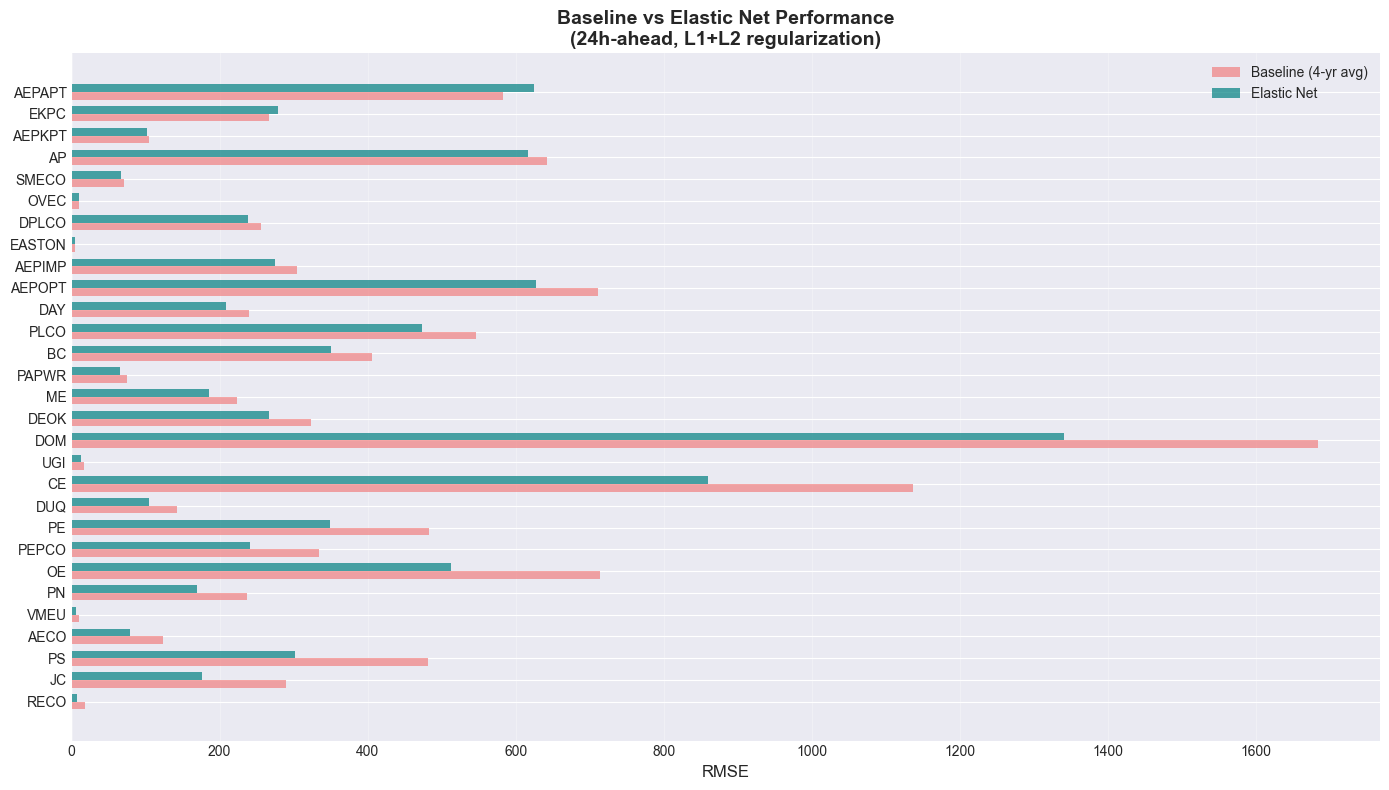

In [7]:
# Baseline vs Elastic Net comparison
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(comparison_df))
width = 0.35

ax.barh(x - width/2, comparison_df['baseline_rmse'], width, label='Baseline (4-yr avg)', alpha=0.7, color='lightcoral')
ax.barh(x + width/2, comparison_df['model_rmse'], width, label='Elastic Net', alpha=0.7, color='teal')

ax.set_yticks(x)
ax.set_yticklabels(comparison_df['area'])
ax.set_xlabel('RMSE', fontsize=12)
ax.set_title('Baseline vs Elastic Net Performance\n(24h-ahead, L1+L2 regularization)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Feature Coefficients Analysis

## Feature Selection Analysis

Analyze which features are selected by Lasso (non-zero coefficients)

In [8]:
print("="*80)
print("FEATURE SELECTION ANALYSIS")
print("="*80)

# Count how many areas use each feature
feature_usage = {feat: 0 for feat in FEATURES}

for idx, row in model_df.iterrows():
    for feat in row['selected_features']:
        feature_usage[feat] += 1

# Create dataframe
feature_usage_df = pd.DataFrame([
    {'feature': k, 'n_areas': v, 'percentage': v/len(model_df)*100}
    for k, v in sorted(feature_usage.items(), key=lambda x: -x[1])
])

print("\nFeature usage across all areas:")
print(feature_usage_df.to_string(index=False))

print(f"\n" + "="*80)
print("MOST IMPORTANT FEATURES (Selected by most areas)")
print("="*80)
print(feature_usage_df.head(5).to_string(index=False))

print(f"\n" + "="*80)
print("LEAST IMPORTANT FEATURES (Rarely or never selected)")
print("="*80)
print(feature_usage_df.tail(5).to_string(index=False))

# Summary statistics
print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total features available: {len(FEATURES)}")
print(f"Average features selected per area: {model_df['n_selected_features'].mean():.1f}")
print(f"Min features selected: {model_df['n_selected_features'].min()}")
print(f"Max features selected: {model_df['n_selected_features'].max()}")
print(f"\nFeatures used by all areas: {(feature_usage_df['n_areas'] == len(model_df)).sum()}")
print(f"Features never used: {(feature_usage_df['n_areas'] == 0).sum()}")

FEATURE SELECTION ANALYSIS

Feature usage across all areas:
        feature  n_areas  percentage
     mw_lag_96h       28   96.551724
  mw_lag_35040h       27   93.103448
    mw_lag_144h       26   89.655172
  mw_lag_26280h       25   86.206897
  mw_lag_17520h       23   79.310345
    mw_lag_168h       23   79.310345
    mw_lag_120h       22   75.862069
    mw_lag_192h       21   72.413793
    mw_lag_216h       20   68.965517
   mw_lag_8760h       18   62.068966
is_thanksgiving       15   51.724138
 is_blackfriday       12   41.379310

MOST IMPORTANT FEATURES (Selected by most areas)
      feature  n_areas  percentage
   mw_lag_96h       28   96.551724
mw_lag_35040h       27   93.103448
  mw_lag_144h       26   89.655172
mw_lag_26280h       25   86.206897
mw_lag_17520h       23   79.310345

LEAST IMPORTANT FEATURES (Rarely or never selected)
        feature  n_areas  percentage
    mw_lag_192h       21   72.413793
    mw_lag_216h       20   68.965517
   mw_lag_8760h       18   62.06896

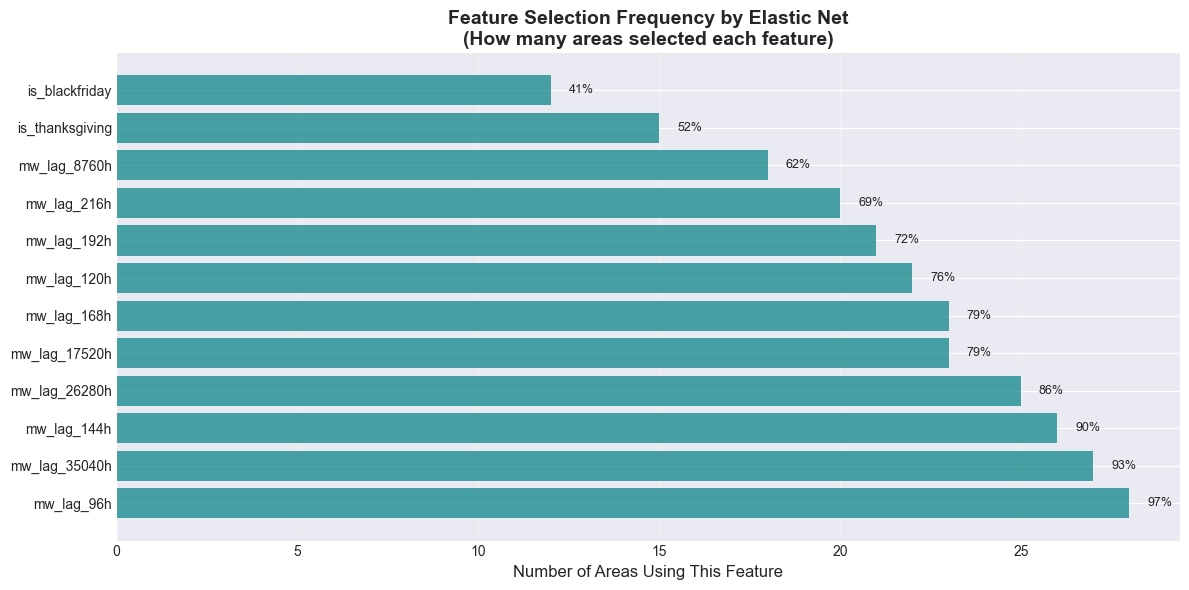

In [9]:
# Visualize feature usage
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(range(len(feature_usage_df)), feature_usage_df['n_areas'], alpha=0.7, color='teal')
ax.set_yticks(range(len(feature_usage_df)))
ax.set_yticklabels(feature_usage_df['feature'])
ax.set_xlabel('Number of Areas Using This Feature', fontsize=12)
ax.set_title('Feature Selection Frequency by Elastic Net\n(How many areas selected each feature)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add percentage labels
for i, row in feature_usage_df.iterrows():
    ax.text(row['n_areas'] + 0.5, i, f"{row['percentage']:.0f}%", 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

## All Areas Beta Coefficients

Show beta coefficients for all areas

In [10]:
print("="*80)
print("LINEAR REGRESSION COEFFICIENTS (BETA VALUES) FOR ALL AREAS")
print("="*80)

# Create dataframe with all coefficients
all_coef_data = []
for idx, row in model_df.iterrows():
    area = row['area']
    coefs = row['coefficients']
    
    coef_dict = {'area': area}
    for i, feat in enumerate(FEATURES):
        coef_dict[feat] = coefs[i]
    
    all_coef_data.append(coef_dict)

all_coef_df = pd.DataFrame(all_coef_data)

# Display
print("\nCoefficients by area:")
print(all_coef_df.to_string(index=False))

# Summary statistics
print(f"\n{'='*80}")
print("COEFFICIENT STATISTICS ACROSS ALL AREAS")
print("="*80)
for feat in FEATURES:
    mean_coef = all_coef_df[feat].mean()
    std_coef = all_coef_df[feat].std()
    min_coef = all_coef_df[feat].min()
    max_coef = all_coef_df[feat].max()
    
    print(f"\n{feat}:")
    print(f"  Mean: {mean_coef:>8.4f}")
    print(f"  Std:  {std_coef:>8.4f}")
    print(f"  Min:  {min_coef:>8.4f}")
    print(f"  Max:  {max_coef:>8.4f}")

# Save to CSV
all_coef_df.to_csv('../dataset/preprocessed/linear_model_coefficients.csv', index=False)
print(f"\n✓ Coefficients saved to: ../dataset/preprocessed/linear_model_coefficients.csv")

LINEAR REGRESSION COEFFICIENTS (BETA VALUES) FOR ALL AREAS

Coefficients by area:
  area  mw_lag_8760h  mw_lag_17520h  mw_lag_26280h  mw_lag_35040h  mw_lag_96h  mw_lag_120h  mw_lag_144h  mw_lag_168h  mw_lag_192h  mw_lag_216h  is_blackfriday  is_thanksgiving
  AECO      0.060096       0.074415       0.115762       0.087829    0.080550     0.098813     0.138745     0.102702     0.036770     0.063482       -0.000194        -0.000112
AEPAPT     -0.000000       0.023438       0.082331       0.170460    0.203417    -0.000000     0.008401     0.101676    -0.091387    -0.069473       -0.000000        -0.000000
AEPIMP     -0.000000      -0.000000       0.000000       0.156334    0.140182     0.000000     0.184918     0.034940    -0.000000    -0.021023       -0.000000        -0.000000
AEPKPT     -0.000000      -0.000000      -0.000000       0.000000    0.048660     0.000000     0.000000     0.000000     0.000000     0.000000       -0.000000        -0.000000
AEPOPT      0.000000       0.016120   

Linear Regression Coefficients (AECO)
        feature  coefficient
    mw_lag_144h     0.138745
  mw_lag_26280h     0.115762
    mw_lag_168h     0.102702
    mw_lag_120h     0.098813
  mw_lag_35040h     0.087829
     mw_lag_96h     0.080550
  mw_lag_17520h     0.074415
    mw_lag_216h     0.063482
   mw_lag_8760h     0.060096
    mw_lag_192h     0.036770
 is_blackfriday    -0.000194
is_thanksgiving    -0.000112


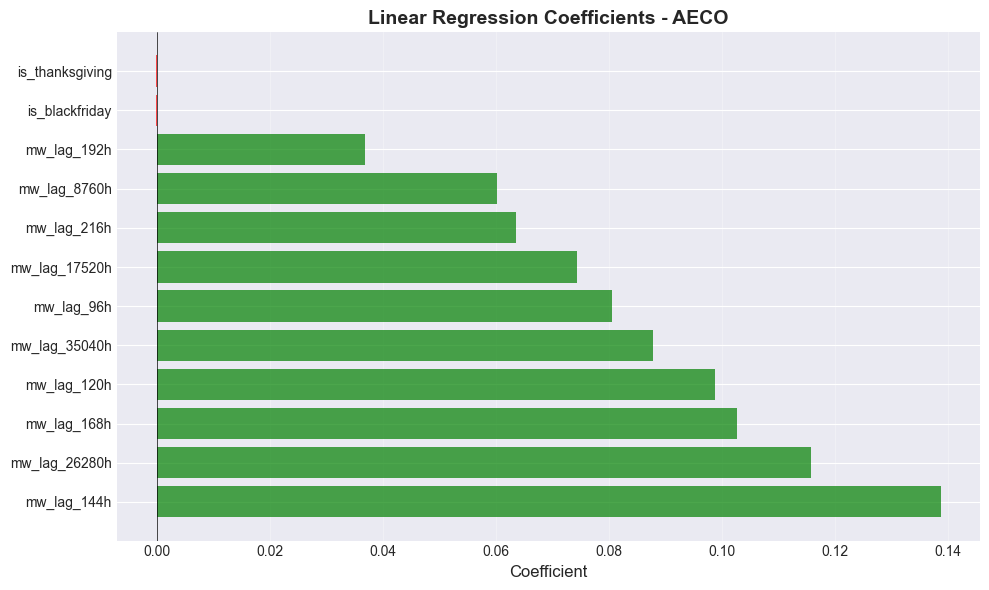

In [11]:
# Analyze coefficients for a sample area
sample_area = 'AECO' if 'AECO' in model_df['area'].values else model_df['area'].iloc[0]
sample_coef = model_df[model_df['area'] == sample_area]['coefficients'].iloc[0]

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': sample_coef
}).sort_values('coefficient', key=abs, ascending=False)

print("="*80)
print(f"Linear Regression Coefficients ({sample_area})")
print("="*80)
print(coef_df.to_string(index=False))

# Plot coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient']]
ax.barh(range(len(coef_df)), coef_df['coefficient'], alpha=0.7, color=colors)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['feature'])
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_title(f'Linear Regression Coefficients - {sample_area}', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Save Models for Production

Save trained Elastic Net models for each area

In [12]:
import pickle
import os

# Create models directory
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save each model
print("="*80)
print("SAVING ELASTIC NET MODELS")
print("="*80)

for idx, row in model_df.iterrows():
    area = row['area']
    
    # Recreate final model with best parameters
    X_all = bf_df[bf_df['load_area'] == area][FEATURES]
    y_all = bf_df[bf_df['load_area'] == area]['target_24h']
    valid_all = X_all.notna().all(axis=1) & y_all.notna()
    X_all_clean = X_all[valid_all]
    y_all_clean = y_all[valid_all]
    
    model = ElasticNet(alpha=row['best_alpha'], l1_ratio=row['best_l1_ratio'], max_iter=10000, random_state=42)
    model.fit(X_all_clean, y_all_clean)
    
    # Save model
    model_path = f"{models_dir}/elasticnet_{area}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    print(f"  ✓ {area:10s} -> {model_path}")

# Save feature list and metadata
metadata = {
    'features': FEATURES,
    'load_areas': load_areas,
    'model_type': 'ElasticNet',
    'horizon_hours': 24
}

metadata_path = f"{models_dir}/model_metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✓ Metadata saved to: {metadata_path}")
print(f"\n{'='*80}")
print(f"✓ All {len(model_df)} models saved successfully")
print(f"{'='*80}")

SAVING ELASTIC NET MODELS
  ✓ AECO       -> ../models/elasticnet_AECO.pkl
  ✓ AEPAPT     -> ../models/elasticnet_AEPAPT.pkl
  ✓ AEPIMP     -> ../models/elasticnet_AEPIMP.pkl
  ✓ AEPKPT     -> ../models/elasticnet_AEPKPT.pkl
  ✓ AEPOPT     -> ../models/elasticnet_AEPOPT.pkl
  ✓ AP         -> ../models/elasticnet_AP.pkl
  ✓ BC         -> ../models/elasticnet_BC.pkl
  ✓ CE         -> ../models/elasticnet_CE.pkl
  ✓ DAY        -> ../models/elasticnet_DAY.pkl
  ✓ DEOK       -> ../models/elasticnet_DEOK.pkl
  ✓ DOM        -> ../models/elasticnet_DOM.pkl
  ✓ DPLCO      -> ../models/elasticnet_DPLCO.pkl
  ✓ DUQ        -> ../models/elasticnet_DUQ.pkl
  ✓ EASTON     -> ../models/elasticnet_EASTON.pkl
  ✓ EKPC       -> ../models/elasticnet_EKPC.pkl
  ✓ JC         -> ../models/elasticnet_JC.pkl
  ✓ ME         -> ../models/elasticnet_ME.pkl
  ✓ OE         -> ../models/elasticnet_OE.pkl
  ✓ OVEC       -> ../models/elasticnet_OVEC.pkl
  ✓ PAPWR      -> ../models/elasticnet_PAPWR.pkl
  ✓ PE         ->